In [1]:
from keras.datasets import mnist
(train_X, train_y), (test_X, test_y) = mnist.load_data()
print('X_train: ' + str(train_X.shape))
print('Y_train: ' + str(train_y.shape))
print('X_test:  ' + str(test_X.shape))
print('Y_test:  ' + str(test_y.shape))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


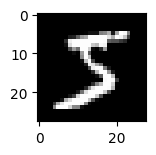

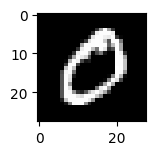

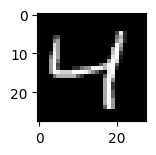

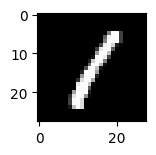

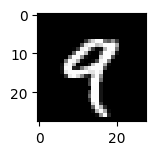

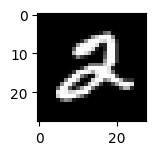

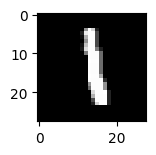

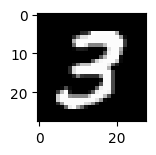

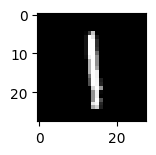

In [2]:
from matplotlib import pyplot
for i in range(9):
  pyplot.subplot(330 + 1 + i)
  pyplot.imshow(train_X[i], cmap=pyplot.get_cmap('gray'))
  pyplot.show()

In [4]:
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [5]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print('X_train: ' + str(train_X.shape))
print('Y_train: ' + str(train_y.shape))
print('X_test:  ' + str(test_X.shape))
print('Y_test:  ' + str(test_y.shape))
num_pixels = X_train.shape[1] * X_train.shape[2]
X_train = X_train.reshape((X_train.shape[0], num_pixels)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], num_pixels)).astype('float32')

X_train = X_train / 255
X_test = X_test / 255

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
num_classes = y_test.shape[1]

X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


In [6]:
model = Sequential()
model.add(Dense(num_pixels, input_dim=num_pixels, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=10, verbose=2)

Epoch 1/5
6000/6000 - 60s - 10ms/step - accuracy: 0.9459 - loss: 0.1757 - val_accuracy: 0.9695 - val_loss: 0.0998
Epoch 2/5
6000/6000 - 76s - 13ms/step - accuracy: 0.9755 - loss: 0.0794 - val_accuracy: 0.9779 - val_loss: 0.0736
Epoch 3/5
6000/6000 - 51s - 9ms/step - accuracy: 0.9829 - loss: 0.0545 - val_accuracy: 0.9704 - val_loss: 0.1079
Epoch 4/5
6000/6000 - 51s - 9ms/step - accuracy: 0.9862 - loss: 0.0433 - val_accuracy: 0.9786 - val_loss: 0.0780
Epoch 5/5
6000/6000 - 84s - 14ms/step - accuracy: 0.9897 - loss: 0.0327 - val_accuracy: 0.9803 - val_loss: 0.0836


In [9]:
scores = model.evaluate(X_test, y_test, verbose=0)
print("Baseline Error: %.2f%%" % (100-scores[1]*100))

Baseline Error: 1.97%


In [10]:
print("Accuracy: %.2f%%" % (scores[1]*100))

Accuracy: 98.03%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


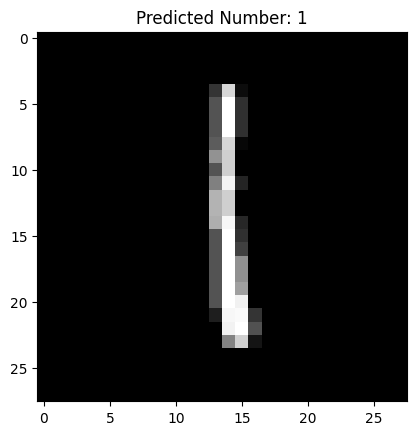

In [11]:
image_index = np.random.randint(0, len(X_test))
image = X_test[image_index]

image = image.reshape(1, 784)

prediction = model.predict(image)

predicted_class = np.argmax(prediction)

plt.imshow(image.reshape(28, 28), cmap='gray')
plt.title(f"Predicted Number: {predicted_class}")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


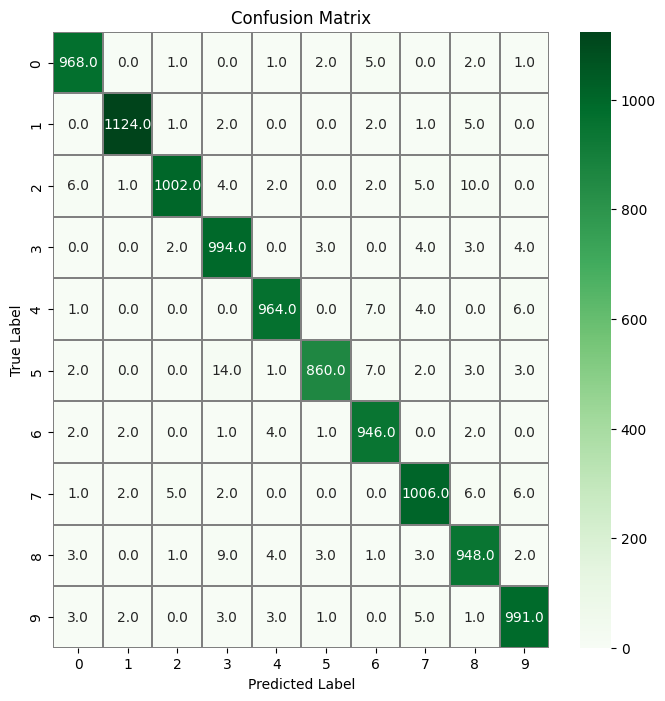

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

#predict the values from the validation dataset
Y_pred = model.predict(X_test)

#convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(Y_pred,axis=1)

#convert validation observations to one hot vectors
Y_true = np.argmax(y_test,axis=1)

#compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

#plot the confusion matrix
f,ax = plt.subplots(figsize=(8, 8))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.01, cmap="Greens", linecolor="gray", fmt= '.1f',ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Enter an image index between 0 and 9999: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


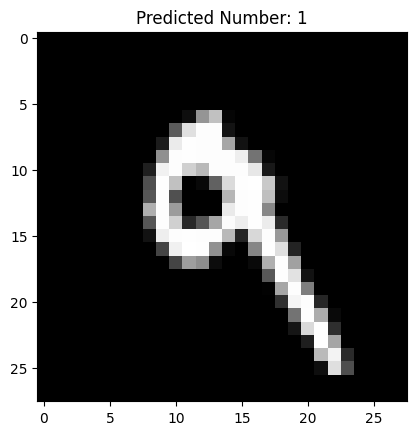

In [14]:
while True:
  try:
    image_index = int(input("Enter an image index between 0 and {}: ".format(len(X_test) - 1)))
    if 0 <= image_index < len(X_test):
      break
    else:
      print("Invalid index. Please enter a number within the range.")
  except ValueError:
    print("Invalid input. Please enter an interger.")

image = X_test[image_index]
image = image.reshape(1, 784)

prediction = model.predict(image)
prediction_class = np.argmax(prediction)

plt.imshow(image.reshape(28, 28), cmap='gray')
plt.title(f"Predicted Number: {predicted_class}")
plt.show()